In [1]:
from datasets import load_dataset
# import musdb
# import nussl
import math
import io
import os
import soundfile as sf
import sounddevice as sd # To run sound using data as array and the sample rate
from datasets import Audio
from torch.utils.data import DataLoader
import numpy as np
from matplotlib import pyplot as plt
from torch.utils.data import ConcatDataset
# import torchcodec
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import Dataset
import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch import Trainer
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [21]:
# import torchaudio
# !pip install soundfile
# !pip install nussl

In [65]:
# music_dataset1 = load_dataset("cs229-audio-ml-project/musdb18-processed", download_mode="force_redownload")
# dataset = load_dataset("musdb")
# mus = musdb.DB(download=True)

In [ ]:
mus[0].audio

In [2]:
dataset1 = load_dataset("MBZUAI/ClArTTS")
dataset2 = load_dataset("MohamedRashad/common-voice-18-arabic")
# music_dataset1 = load_dataset("cs229-audio-ml-project/musdb18-processed")

Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/21 [00:00<?, ?it/s]

In [2]:
def decode_audio(example):
    audio = example["audio"]

    # case 1: bytes (your current situation)
    if isinstance(audio, dict) and "bytes" in audio:
        waveform, sr = sf.read(io.BytesIO(audio["bytes"]), dtype="float32")

    # case 2: file path (sometimes HF gives this)
    elif isinstance(audio, dict) and "path" in audio:
        waveform, sr = sf.read(audio["path"], dtype="float32")

    # case 3: already decoded
    elif isinstance(audio, dict) and "array" in audio:
        waveform = audio["array"]
        sr = audio["sampling_rate"]

    else:
        raise ValueError("Unknown audio format")

    example["audio"] = waveform.astype(np.float32)
    example["sr"] = sr
    return example

In [5]:
# This library differ from CLArTTS, it requires a specific dependency which is torchcodec. 
# that specific library is not working atm, so the easy solution is to turn it off by 
# turning off the decode
dataset2 = dataset2.cast_column("audio", Audio(decode=False)).map(decode_audio, num_proc=8)

In [3]:
base_path = os.path.join("dataset", "musdb18hq", "train")
music_array = []
mixed_audio = []
speech_audio = []

def load_music(folder_path):
    # Load files (automatically resamples if needed)
    mixture = os.path.join(folder_path, "mixture.wav")
    vocal = os.path.join(folder_path, "vocals.wav")
    
    audio1, sr1 = sf.read(mixture)
    audio2, sr2 = sf.read(vocal)  # force same sample rate
    
    # Match lengths
    min_len = min(len(audio1), len(audio2))
    audio1 = audio1[:min_len]
    audio2 = audio2[:min_len]
    
    # Subtract
    music_only_audio = audio1 - audio2
    
    # Normalize to avoid clipping
    # result = result / np.max(np.abs(result))
    
    # Save output
    # sf.write("output.wav", result, sr1)
    
    # print("Done!")
    # return music_only_audio
    return audio1, music_only_audio#, audio2

for subfolder in os.listdir(base_path):
    folder_path = os.path.join(base_path, subfolder)
    
    if os.path.isdir(folder_path):
        wav_files = [f for f in os.listdir(folder_path) if f.endswith(".wav")]
        
        if len(wav_files) == 5:
            # file1 = os.path.join(folder_path, wav_files[0])
            # file2 = os.path.join(folder_path, wav_files[1])
            # loaded_music = load_music(folder_path)
            # loaded_music = loaded_music.reshape(loaded_music.shape[1], -1)
            x, y = load_music(folder_path)
            x = x.reshape(x.shape[1], -1)
            y = y.reshape(y.shape[1], -1)
            # for track in loaded_music:
            #     music_array.append(track)
            for track in x:
                mixed_audio.append(np.array(track))
            for track in y:
                speech_audio.append(np.array(track))
        else:
            print("The folder: ", folder_path, " is missing files!")

            # (reuse subtraction code here)

# Notes

## Augmentation Related
### Note 1
The model should be time wrapping invariance (able to handle different sampling rate)
To that end, it is important to have a resampling augmentation
### Note 2
The input can be as long as 40100 data points if the model were to handle one second at a time.
This can make the model quite large, thus, this input will need to be split, or projected down
to make sure the model size will stay relatively small.


## Architecture Related
### Note 1
Using an encoder and decoder together might be better than just using an encoder or a decoder.
The idea is the encoder will get information about a larger chunk, let's say 5-10 seconds, while
the decoder will process 1 second at a time. This means the encoder will gain insight about 
a larger chunk, (more global attention), this means it will figure out which sound effect to 
remove and which one to keep. Maybe a sound effect is needed, such as a mouse click, and maybe
it is noise, so this larger attention might help in those kind of scenarios.

# Visualizing Data

In [28]:
dataset1.keys()

dict_keys(['train', 'test'])

In [27]:
dataset1["train"][0].keys()

dict_keys(['text', 'file', 'audio', 'sampling_rate', 'duration'])

In [10]:
dataset2

DatasetDict({
    train: Dataset({
        features: ['client_id', 'path', 'audio', 'sentence', 'up_votes', 'down_votes', 'age', 'gender', 'accent', 'locale', 'segment', 'variant'],
        num_rows: 28410
    })
    validation: Dataset({
        features: ['client_id', 'path', 'audio', 'sentence', 'up_votes', 'down_votes', 'age', 'gender', 'accent', 'locale', 'segment', 'variant'],
        num_rows: 10471
    })
    test: Dataset({
        features: ['client_id', 'path', 'audio', 'sentence', 'up_votes', 'down_votes', 'age', 'gender', 'accent', 'locale', 'segment', 'variant'],
        num_rows: 10471
    })
    other: Dataset({
        features: ['client_id', 'path', 'audio', 'sentence', 'up_votes', 'down_votes', 'age', 'gender', 'accent', 'locale', 'segment', 'variant'],
        num_rows: 41586
    })
    invalidated: Dataset({
        features: ['client_id', 'path', 'audio', 'sentence', 'up_votes', 'down_votes', 'age', 'gender', 'accent', 'locale', 'segment', 'variant'],
        num_

200
200


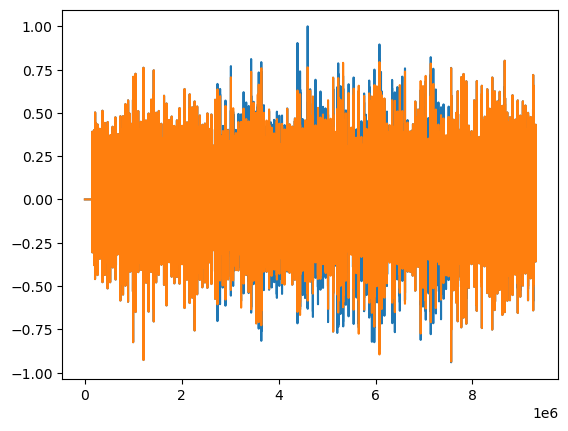

In [4]:
print(len(mixed_audio))
print(len(speech_audio))
r_i = np.random.randint(0, len(mixed_audio))
plt.plot(mixed_audio[r_i])
plt.plot(speech_audio[r_i])
# transform = torchaudio.transforms.Spectrogram(n_fft=800)
# plt.plot(transform(mixed_audio[r_i]))

In [29]:
exampleAudioI = 1000
audio_e_data = dataset1["train"][exampleAudioI]["audio"]
audio_e_samplerate = dataset1["train"][exampleAudioI]["sampling_rate"]

In [ ]:
plt.plot(dataset2["train"][exampleAudioI]["audio"])

In [31]:
sd.play(data=audio_e_data, samplerate=audio_e_samplerate)

In [ ]:
plt.plot(audio_e_data)

# Merge Datasets

# Dataset Augmentation

In [5]:
def get_rms(records):
    return math.sqrt(sum([x ** 2 for x in records]) / len(records))
    
def get_random_part(array, chunk_size):
    if len(array) < chunk_size:
        print("Array size:(", len(array), ") is less then the chunk_size: (", chunk_size, ") in 'get_random_part'")
        pad_width = chunk_size - len(arr)
        return np.pad(arr, (0, pad_width), constant_values=pad_value)
    else:
        diff_size = len(array) - chunk_size
        start = np.random.randint(0, diff_size)
        return array[start:(start + chunk_size)], start

# Test
plt.plot(get_random_part(audio_e_data, audio_e_samplerate))

In [131]:
class WrappedDataset:
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, i):
        audio = self.dataset[i]["audio"]

        # normalize here
        # e.g. resample, pad, trim
        return audio

class SimpleDataset:
    def __init__(self, mixed_data, speech_data, chunk_size):
        self.mixed_data = mixed_data
        self.speech_data = speech_data
        self.chunk_size = chunk_size

    def __len__(self):
        return len(self.mixed_data * 1000)

    def __getitem__(self, i):
        i = i % len(self.mixed_data)
        # Select part of the speech and music equivalent to chunk_size
        mixed_chunk, start = get_random_part(self.mixed_data[i], self.chunk_size)
        speech_chunk = self.speech_data[i][start:(start+self.chunk_size)]
        peak = np.max(np.abs(mixed_chunk))
        if peak > 0:
            mixed_chunk = mixed_chunk / peak
            speech_chunk = speech_chunk / peak
        # music_chunk = get_random_part(music, self.chunk_size)
        return mixed_chunk.reshape(-1, 1).astype(np.float32), speech_chunk.reshape(-1, 1).astype(np.float32)

In [132]:
class AgumenterDataset(Dataset):
    def __init__(self, speech_data, music_data, chunk_size):
        super().__init__()
        self.speech_data = speech_data
        self.music_data = music_data
        self.chunk_size = chunk_size

    def __len__(self):
        return len(self.speech_data)

    def __getitem__(self, i):
        speech = self.speech_data[i]
        music_i = np.random.randint(0, len(self.music_data))
        music = self.music_data[music_i]

        # Select part of the speech and music equivalent to chunk_size
        speech_chunk = get_random_part(speech, self.chunk_size)
        music_chunk = get_random_part(music, self.chunk_size)

        # Calculate signal to noise ratio, and adjust the music based on that
        snr_db = np.random.uniform(-14, 2) # Training samples noise in the range of -7 to 2 snr
        snr = 10 ** (0.1 * (snr_db))
        music_rms = get_rms(music_chunk)
        if music_rms == 0:
            coe = 1
        else:
            coe=get_rms(speech_chunk)/(music_rms*snr)
            
        music_chunk *= coe
        mixed_audio = speech_chunk + music_chunk

        return mixed_audio.reshape(-1, 1).astype(np.float32), np.reshape(speech_chunk, (-1, 1)).astype(np.float32), music_chunk.reshape(-1, 1).astype(np.float32)
        

In [ ]:
speech_dataset = ConcatDataset([
    WrappedDataset(dataset1["train"]),
    WrappedDataset(dataset2["train"]),
])
len(speech_dataset)

In [133]:
chunk_size = 44100 #audio_e_samplerate
music_dataset1 = SimpleDataset(mixed_audio, speech_audio, chunk_size)
# train_dataset = AgumenterDataset(speech_data=speech_dataset, music_data=loaded_music, chunk_size=chunk_size)

In [134]:
batch_size = 8
# train_loader = DataLoader(
#     train_dataset,
#     batch_size=batch_size,
#     shuffle=True
# )
train_loader = DataLoader(
    music_dataset1,
    batch_size=batch_size,
    shuffle=True
)

torch.float32
torch.Size([8, 44100, 1])
torch.float32


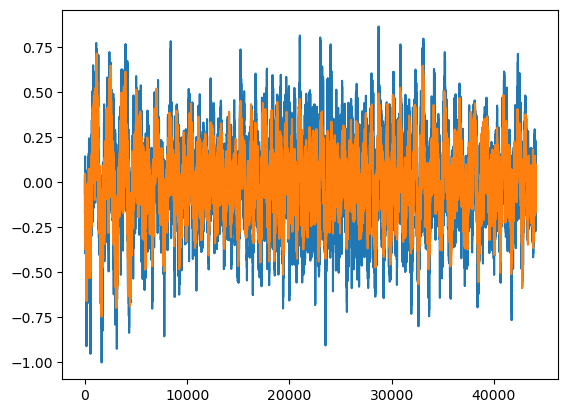

In [136]:

for x, y in train_loader:
    print(x.dtype)
    print(x.shape)
    print(y.dtype)
    # print(z.dtype)
    peak = peak = torch.max(torch.abs(x[7].reshape(-1)))
    sd.play(data=y[7]/peak, samplerate=44100)
    # # print(1)
    plt.plot(x[0])
    # plt.show()
    plt.plot(y[0])
    # plt.show()
    # plt.plot(z)
    # plt.show()
    break

# Model

In [23]:
class MusicRemoverLayer(nn.Module):
    def __init__(self, chunk_size, d_model=32, nhead=4, num_layers=1):
        super().__init__()

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            dropout=0.1, # default
            activation="gelu",
            bias=True,
            nhead=nhead, # Might be better to have multiple head, each focusing on different type of info
            dim_feedforward=chunk_size,
            batch_first=True, # Shape (B, Seq, D_model)
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, x): # Input must be (B, Seq, D_model)!
        music_noise = self.transformer(x)
        cleaned_x = (x - music_noise)
        return cleaned_x

In [24]:
# Transformer model for signal input
class LinearProjectionLayer(nn.Module):
    def __init__(self, from_size, to_size, last=False):
        super().__init__()
        self.linear = nn.Linear(from_size, to_size)
        self.last = last


    def forward(self, x):
        # x shape: # (B, 1, S)
        # print("Before: ", x.shape)
        if not(self.last):
            x = x.permute(0, 2, 1)
        x = self.linear(x)              # (B, S, 1)
        # print("After: ", x.shape)

        if not(self.last):
            out = x.permute(0, 2, 1)
        else:
            out = x
        # print(out.shape)
        return out
        
class PermuteLastLayer(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        # print(x.shape)
        return x.permute(0, 2, 1)

In [25]:
class Encoder(nn.Module):
    def __init__(self, chunk_size, chunks, d_model, nhead, latent):
        super().__init__()
        self.input_dim = 1
        self.layer = nn.Sequential(
            LinearProjectionLayer(chunk_size * chunks, chunk_size), # Decrease sequence length
            LinearProjectionLayer(chunk_size, chunk_size // 2), # Decrease sequence length
            LinearProjectionLayer(chunk_size // 2, latent), # Decrease sequence length to latent (aligning latent space)
            LinearProjectionLayer(self.input_dim, d_model, last=True), # increase/decrease dimensions to d_model
            MusicRemoverLayer(chunk_size = chunk_size // 4, d_model = d_model, nhead = nhead), # I need to test on multiple layers
        )

    def forward(self, x):
        return self.layer(x) # output shape (B, latent, d_model)

In [26]:
class Decoder(nn.Module):
    def __init__(self, chunk_size, d_model, nhead, latent):
        super().__init__()
        self.input_dim = 1
        self.layer = nn.Sequential(
            LinearProjectionLayer(chunk_size, chunk_size // 2), # Decrease sequence length
            LinearProjectionLayer(chunk_size // 2, latent), # Decrease sequence length to latent (aligning latent space)
            LinearProjectionLayer(self.input_dim, d_model, last=True), # increase/decrease dimensions to d_model
            MusicRemoverLayer(chunk_size = chunk_size // 4, d_model = d_model, nhead = nhead), # I need to test on multiple layers
            # I project down to 1 dim, then increase seq length for efficency purposes. However, the opposite could be tested
            LinearProjectionLayer(d_model, self.input_dim, last=True), # convert dimension back to input_dim
            LinearProjectionLayer(latent, chunk_size), # convert seq length back to chunk_size
        )

    def forward(self, x):
        return self.layer(x) # output shape (B, chunk_size, 1)

In [27]:
class DecoderConv(nn.Module):
    def __init__(self, chunk_size, d_model, nhead, latent):
        super().__init__()
        self.k = 8
        self.input_dim = 1
        self.layer = nn.Sequential(
            # LinearProjectionLayer(chunk_size, chunk_size // 2), # Decrease sequence length
            # LinearProjectionLayer(chunk_size // 2, latent), # Decrease sequence length to latent (aligning latent space)
            # LinearProjectionLayer(self.input_dim, d_model, last=True), # increase/decrease dimensions to d_model
            
            nn.Conv1d(1, d_model, self.k, stride=(4), padding=3), # 44100 --> 11025
            nn.ReLU(),
            nn.Conv1d(d_model, d_model, self.k, stride=(5), padding=3), # 11025 --> 2205
            nn.ReLU(),
            LinearProjectionLayer(2005, latent, last=True), # Decrease to latent
            nn.ReLU(),
            PermuteLastLayer(),
            MusicRemoverLayer(chunk_size = chunk_size // 4, d_model = d_model, nhead = nhead), # I need to test on multiple layers
            nn.ReLU(),
            # I project down to 1 dim, then increase seq length for efficency purposes. However, the opposite could be tested
            # LinearProjectionLayer(d_model, self.input_dim, last=True), # convert dimension back to input_dim
            LinearProjectionLayer(latent, 2005),#, last=True), # Decrease to latent
            nn.ReLU(),
            PermuteLastLayer(),
            nn.ConvTranspose1d(d_model, 1, self.k, stride=(5), padding=3), # 11025 --> 2205
            nn.ReLU(),
            # nn.ConvTranspose1d(1, 1, k, stride=(4), padding=3), # 44100 --> 11025
            # LinearProjectionLayer(latent, chunk_size), # convert seq length back to chunk_size
        )

    def forward(self, x):
        # print("Before: ", x.shape)
        x = x.permute(0, 2, 1)
        # print("After: ", x.shape)
        return self.layer(x) # output shape (B, chunk_size, 1)

In [28]:
class MusicRemoverModel(L.LightningModule):
    def __init__(self, chunk_size=250, d_model=32, nhead=4, latent=512, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.layer = nn.Sequential(
          Decoder(chunk_size=chunk_size, d_model=d_model, nhead=nhead, latent=512)
        );
        self.loss_fn = nn.MSELoss()

    def forward(self, x):
        return self.layer(x)

    def training_step(self, batch, batch_idx):
        x, y, z = batch
        predicted_y = self(x)
        loss = self.loss_fn(predicted_y, y)
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True, logger=True)
        return loss

    def configure_optimizers(self):
        self.optimizer = optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=1e-2)
        return self.optimizer

In [71]:
class MusicRemoverModelConv(L.LightningModule):
    def __init__(self, chunk_size=250, d_model=32, nhead=4, latent=512, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr
        self.layer = nn.Sequential(
          # DecoderConv(chunk_size=chunk_size, d_model=d_model, nhead=nhead, latent=latent)
            PermuteLastLayer(),
            nn.Linear(chunk_size, latent, ),
            nn.ReLU(),
            nn.Linear(latent, latent),
            nn.ReLU(),
            nn.Linear(latent, latent),
            nn.ReLU(),
            nn.Linear(latent, chunk_size),
            PermuteLastLayer(),
        );
        self.loss_fn = nn.MSELoss()

    def forward(self, x):
        return self.layer(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        predicted_y = self(x)
        loss = self.loss_fn(predicted_y, y)
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True, logger=True)
        return loss

    def configure_optimizers(self):
        self.optimizer = optim.AdamW(self.parameters(), lr=self.lr, weight_decay=1e-2)
        return self.optimizer

In [137]:
# model = MusicRemoverModel(chunk_size=chunk_size, d_model=32, nhead=4, latent=512, lr=1e-3)
model = MusicRemoverModelConv(chunk_size=chunk_size, d_model=32, nhead=4, latent=512, lr=1e-2)

In [ ]:
trainer = L.Trainer(
    max_epochs=1000,
    accelerator="gpu",
    devices=1,
    log_every_n_steps=5,
    # gradient_clip_val=1.0,
    # detect_anomaly=True,
    # callbacks=[
    #     checkpoint_callback,
    #     ModelEvaluatorCallback()
    # ]
)

# train_dataset.astype(np.float32)

trainer.fit(
    model,
    train_dataloaders=train_loader,
    # val_dataloaders=val_loader
)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type       | Params | Mode 
-----------------------------------------------
0 | layer   | Sequential | 45.7 M | train
1 | loss_fn | MSELoss    | 0      | train
-----------------------------------------------
45.7 M    Trainable params
0         Non-trainable params
45.7 M    Total params
182.913   Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

(44100, 1)


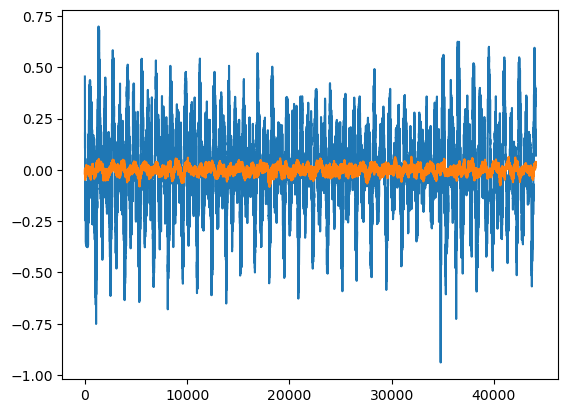

In [124]:
for x, y in music_dataset1:
    # sd.play(data=x, samplerate=audio_e_samplerate)
    print(x.shape)
    speech = model(torch.from_numpy(x.reshape(1, -1, 1))).cpu().detach().numpy().reshape(-1, 1)
    plt.plot(y)
    plt.plot(speech)
    sd.play(speech, samplerate=chunk_size)
    # plt.plot(z)
    break

In [342]:
#torch.nn.Conv1d(in_channels, out_channels, kernel_size, stride=1, padding=0, dilation=1, groups=1, bias=True, padding_mode='zeros', device=None, dtype=None)
#nn.ConvTranspose1d(in_channels, out_channels, kernel_size, stride=1, padding=0, output_padding=0, groups=1, bias=True, dilation=1, padding_mode='zeros', device=None, dtype=None)
k = 8
con_test = nn.Conv1d(1, 32, k, stride=(4), padding=3)
con_test1 = nn.Conv1d(32, 32, k, stride=(5), padding=3)

In [343]:
a = [0.0]*44100
a = torch.tensor(a, dtype=torch.float32)
a = a.unsqueeze(0).unsqueeze(0)
a_con_out = con_test(a)
a_con_out2 = con_test1(a_con_out)

In [344]:
print(a_con_out.shape)
print(a_con_out2.shape)

torch.Size([1, 32, 11025])
torch.Size([1, 32, 2205])
